# Friedman test across datasets (mean AEC & mean AUROC)

This notebook **reads stored results** from the experiment notebooks (`churn.ipynb`, `gmsc.ipynb`, `upsell.ipynb`, optionally `pakdd.ipynb`) by parsing the **saved `display` output** for the summary table with **`AEC_mean`** and **`AUROC_mean`** (both **`text/plain`** and **`text/html`** are supported — HTML uses `lxml`, `bs4`, or `html5lib` so it still works if `lxml` is not installed).

If the notebook cannot find `churn.ipynb`, set the environment variable **`EXPERIMENT_REPO`** to your project folder, or run Jupyter with the project folder as the working directory.

**Setup (Demšar-style):** each **dataset** is one *block*. For each dataset you have one **mean AEC** and one **mean AUROC** per model. Separate **Friedman tests** are run for each metric: **lower AEC** is better (ranks ascending), **higher AUROC** is better (ranks descending). When Friedman rejects equality of treatments, **Nemenyi** post-hoc compares all pairs of models: if the absolute difference of **average ranks** exceeds the **critical difference (CD)**, that pair is considered significantly different at the chosen alpha (same rule as in Demšar 2006).

Exports: `results/cross_dataset_aec.csv`, `results/cross_dataset_auroc.csv`, and optional `results/nemenyi_pairwise_*.csv` for pairwise rank differences and significance flags.

**Canonical model set (for column order and missing-model hints):** the first code cell defines `CANONICAL_MODEL_ORDER` aligned with the main experiment notebooks, **excluding `transfer_nn`** so cross-dataset Friedman does not depend on that run. Friedman still uses only the **intersection** of models present in every loaded dataset; the notebook prints which canonical names are missing so you know what to re-run.



In [1]:
import json
import os
import re
from typing import Dict, List, Optional

from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats


def find_repo_root() -> Path:
    """Resolve folder that contains churn.ipynb (cwd may differ in Jupyter)."""
    env = os.environ.get('EXPERIMENT_REPO', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'churn.ipynb').is_file():
            return p
    cwd = Path.cwd().resolve()
    for anchor in ('churn.ipynb', 'gmsc.ipynb'):
        for p in [cwd, *cwd.parents]:
            if (p / anchor).is_file():
                return p
    return cwd


REPO_ROOT = find_repo_root()
print(f'Experiment notebooks directory: {REPO_ROOT}')

# Notebook paths relative to repo root (edit if needed)
NOTEBOOK_PATHS = {
    'churn': REPO_ROOT / 'churn.ipynb',
    'gmsc': REPO_ROOT / 'gmsc.ipynb',
    'upsell': REPO_ROOT / 'upsell.ipynb',
    'pakdd': REPO_ROOT / 'pakdd.ipynb',
}

# CSV exports use metric column names (see load cell).
ALPHA = 0.05
# (metric_column, rank_ascending): lower rank = better for both after ranking
METRICS_CONFIG = [
    ('AEC_mean', True),   # lower AEC is better
    ('AUROC_mean', False),  # higher AUROC is better
]
CANONICAL_MODEL_ORDER = [
    'logit', 'cslogit', 'boost', 'csboost',
    'layer_proba_safe', 'weighted_xgb_aec', 'costloss_xgb',
    'transfer_xgb', 'transfer_xgb_fullcs', 'curriculum_xgb',
    'teacher_csboost', 'hybrid_aug_xgb', 'hybrid_aug_mlp',
]
# transfer_nn omitted on purpose (heavy / optional for cross-dataset table).




Experiment notebooks directory: /Users/lea/final cost sensitive 


In [2]:
def _join_mime(data: dict, key: str) -> Optional[str]:
    raw = data.get(key)
    if not raw:
        return None
    return ''.join(raw) if isinstance(raw, list) else raw


def _read_html_tables(html: str) -> List[pd.DataFrame]:
    """Try several parsers — lxml is optional; without it read_html may fail."""
    out: List[pd.DataFrame] = []
    for flavor in ('lxml', 'bs4', 'html5lib', None):
        try:
            dfs = pd.read_html(StringIO(html), flavor=flavor)
            if dfs:
                return list(dfs)
        except (ImportError, ValueError, OSError):
            continue
    return out


def _metrics_df_from_html_df(df: pd.DataFrame) -> Optional[pd.DataFrame]:
    """Wide summary: AEC_mean + AUROC_mean per model."""
    cols = df.columns
    if isinstance(cols, pd.MultiIndex):
        lev0 = cols.get_level_values(0)
        has_aec = 'AEC_mean' in lev0
        has_auc = 'AUROC_mean' in lev0
    else:
        has_aec = 'AEC_mean' in cols
        has_auc = 'AUROC_mean' in cols
    if not (has_aec and has_auc):
        return None
    if df.index.name == 'Model' or (len(df.index) and str(df.index[0]) not in ('0', '1', '2')):
        models = df.index.astype(str)
        aec_c = [c for c in df.columns if (isinstance(c, tuple) and c[0] == 'AEC_mean') or c == 'AEC_mean']
        auc_c = [c for c in df.columns if (isinstance(c, tuple) and c[0] == 'AUROC_mean') or c == 'AUROC_mean']
        if not aec_c or not auc_c:
            return None
        out = pd.DataFrame({'AEC_mean': df[aec_c[0]].values, 'AUROC_mean': df[auc_c[0]].values}, index=models)
    else:
        mcol = df.columns[0]
        models = df[mcol].astype(str)
        if len(models) == 0 or str(models.iloc[0]).strip().lower() == 'model':
            return None
        aec_c = [c for c in df.columns if (isinstance(c, tuple) and c[0] == 'AEC_mean') or c == 'AEC_mean']
        auc_c = [c for c in df.columns if (isinstance(c, tuple) and c[0] == 'AUROC_mean') or c == 'AUROC_mean']
        if not aec_c or not auc_c:
            return None
        out = pd.DataFrame({'AEC_mean': df[aec_c[0]].values, 'AUROC_mean': df[auc_c[0]].values}, index=models.values)
    out.index.name = 'Model'
    return out.astype(float)


def _parse_aec_block_plain(plain: str) -> Optional[pd.Series]:
    if 'AEC_mean' not in plain or 'Brier_mean' not in plain:
        return None
    best = None
    for block in plain.strip().split('\n\n'):
        lines = [ln.rstrip() for ln in block.splitlines() if ln.strip()]
        if not lines:
            continue
        head = lines[0]
        if 'AEC_mean' not in head or 'Brier_mean' not in head or 'train_AEC_mean' in head:
            continue
        rows = []
        for ln in lines[1:]:
            parts = ln.split()
            if len(parts) < 2 or parts[0] == 'Model':
                continue
            try:
                aec = float(parts[1])
            except ValueError:
                continue
            if not re.match(r'^[A-Za-z]', parts[0]):
                continue
            rows.append((parts[0], aec))
        if len(rows) >= 2:
            s = pd.Series({m: v for m, v in rows}, name='AEC_mean')
            if best is None or len(s) > len(best):
                best = s
    return best


def _parse_auroc_from_plain(plain: str) -> Dict[str, float]:
    """Second text block: ... AUROC_mean AP_mean ..."""
    out: Dict[str, float] = {}
    for block in plain.strip().split('\n\n'):
        lines = [ln.rstrip() for ln in block.splitlines() if ln.strip()]
        if not lines:
            continue
        head = lines[0]
        if 'AUROC_mean' not in head:
            continue
        hdr = head.split()
        if 'AUROC_mean' not in hdr:
            continue
        i_auc = hdr.index('AUROC_mean')
        for ln in lines[1:]:
            parts = ln.split()
            if len(parts) < 2 + i_auc or parts[0] == 'Model':
                continue
            try:
                out[parts[0]] = float(parts[1 + i_auc])
            except (ValueError, IndexError):
                continue
    return out


def _metrics_from_plain(plain: str) -> Optional[pd.DataFrame]:
    if 'AUROC_mean' not in plain:
        return None
    aec = _parse_aec_block_plain(plain)
    if aec is None or len(aec) < 2:
        return None
    auc_map = _parse_auroc_from_plain(plain)
    common = sorted(set(aec.index) & set(auc_map.keys()))
    if len(common) < 2:
        return None
    return pd.DataFrame(
        {'AEC_mean': aec.loc[common].values, 'AUROC_mean': [auc_map[m] for m in common]},
        index=common,
    )


def extract_metrics_table_from_notebook(path: Path) -> Optional[pd.DataFrame]:
    """Parse summary with AEC_mean and AUROC_mean from saved outputs."""
    path = Path(path)
    if not path.is_file():
        print(f'  [skip] missing file: {path}')
        return None
    with open(path, encoding='utf-8') as f:
        nb = json.load(f)
    candidates: List[pd.DataFrame] = []
    for cell in nb.get('cells', []):
        for out in cell.get('outputs', []):
            if out.get('output_type') not in ('display_data', 'execute_result'):
                continue
            data = out.get('data', {})
            plain = _join_mime(data, 'text/plain')
            if plain and 'AEC_mean' in plain and 'AUROC_mean' in plain:
                t = _metrics_from_plain(plain)
                if t is not None and len(t) >= 2:
                    candidates.append(t)
            html = _join_mime(data, 'text/html')
            if not html or 'AEC_mean' not in html:
                continue
            for df in _read_html_tables(html):
                t = _metrics_df_from_html_df(df)
                if t is not None and len(t) >= 2:
                    candidates.append(t)
    if not candidates:
        return None
    return max(candidates, key=lambda d: len(d))


def load_all_metric_tables(paths: Dict[str, Path]) -> Dict[str, pd.DataFrame]:
    out: Dict[str, pd.DataFrame] = {}
    for name, p in paths.items():
        print(f'Loading {name} from {p.name}...')
        t = extract_metrics_table_from_notebook(p)
        if t is None or len(t) == 0:
            print(f'  [warn] no AEC+AUROC summary table found; skip dataset "{name}".')
            continue
        if len(t) < 2:
            print(
                f'  [warn] only {len(t)} model(s) — dataset "{name}" incomplete; excluded.'
            )
            continue
        out[name] = t
        print(f'  -> {len(t)} models (AEC + AUROC)')
    return out

In [3]:
tables_by_ds = load_all_metric_tables(NOTEBOOK_PATHS)

if len(tables_by_ds) < 3:
    raise RuntimeError(
        'Need at least 3 datasets with full summary tables for a meaningful Friedman test. '
        f'Got: {list(tables_by_ds.keys())}'
    )

common_set = None
for t in tables_by_ds.values():
    idx = set(t.index.astype(str))
    common_set = idx if common_set is None else (common_set & idx)

missing_all = [m for m in CANONICAL_MODEL_ORDER if m not in common_set]
if missing_all:
    print(
        '\n[info] These canonical models are not in ALL parsed summaries yet '
        '(re-run each dataset notebook through the summary table cell to include them):'
    )
    print(' ', missing_all)

for ds_name, t in tables_by_ds.items():
    have = set(t.index.astype(str))
    miss_ds = [m for m in CANONICAL_MODEL_ORDER if m not in have]
    if miss_ds:
        print(f'  [info] {ds_name}: missing vs canonical → {miss_ds}')

extras = sorted(m for m in common_set if m not in CANONICAL_MODEL_ORDER)
common_models = [m for m in CANONICAL_MODEL_ORDER if m in common_set] + extras
print(f'\nModels present in all {len(tables_by_ds)} datasets ({len(common_models)}): {common_models}')

if len(common_models) < 3:
    raise RuntimeError('Need at least 3 models in common across all datasets for Friedman (k>=3).')

M_aec = pd.DataFrame(
    {ds: t.loc[common_models, 'AEC_mean'] for ds, t in tables_by_ds.items()}
).T
M_aec.index.name = 'dataset'
M_aec.columns.name = 'Model'
M_auroc = pd.DataFrame(
    {ds: t.loc[common_models, 'AUROC_mean'] for ds, t in tables_by_ds.items()}
).T
M_auroc.index.name = 'dataset'
M_auroc.columns.name = 'Model'

print('Mean AEC (datasets × models):')
display(M_aec)
print('Mean AUROC (datasets × models):')
display(M_auroc)

out_dir = REPO_ROOT / 'results'
out_dir.mkdir(parents=True, exist_ok=True)
for path, M in (
    (out_dir / 'cross_dataset_aec.csv', M_aec),
    (out_dir / 'cross_dataset_auroc.csv', M_auroc),
):
    M.to_csv(path)


Loading churn from churn.ipynb...
  -> 12 models (AEC + AUROC)
Loading gmsc from gmsc.ipynb...
  -> 12 models (AEC + AUROC)
Loading upsell from upsell.ipynb...
  -> 12 models (AEC + AUROC)
Loading pakdd from pakdd.ipynb...
  [warn] no AEC+AUROC summary table found; skip dataset "pakdd".

[info] These canonical models are not in ALL parsed summaries yet (re-run each dataset notebook through the summary table cell to include them):
  ['hybrid_aug_mlp']
  [info] churn: missing vs canonical → ['hybrid_aug_mlp']
  [info] gmsc: missing vs canonical → ['hybrid_aug_mlp']
  [info] upsell: missing vs canonical → ['hybrid_aug_mlp']

Models present in all 3 datasets (12): ['logit', 'cslogit', 'boost', 'csboost', 'layer_proba_safe', 'weighted_xgb_aec', 'costloss_xgb', 'transfer_xgb', 'transfer_xgb_fullcs', 'curriculum_xgb', 'teacher_csboost', 'hybrid_aug_xgb']
Mean AEC (datasets × models):


Model,logit,cslogit,boost,csboost,layer_proba_safe,weighted_xgb_aec,costloss_xgb,transfer_xgb,transfer_xgb_fullcs,curriculum_xgb,teacher_csboost,hybrid_aug_xgb
dataset,,,,,,,,,,,,
churn,60.995706,58.205073,59.727971,50.673939,60.143616,58.552724,58.907206,58.665607,57.530163,58.013129,51.157843,50.804488
gmsc,716.799410,393.292908,605.306103,368.434667,741.645994,483.136131,482.625877,486.918795,486.424609,484.441506,359.137385,359.943516
upsell,1.272133,0.802670,1.255793,0.514364,0.580808,0.704462,0.694660,0.703463,0.701658,0.701419,0.509777,0.543203


Mean AUROC (datasets × models):


Model,logit,cslogit,boost,csboost,layer_proba_safe,weighted_xgb_aec,costloss_xgb,transfer_xgb,transfer_xgb_fullcs,curriculum_xgb,teacher_csboost,hybrid_aug_xgb
dataset,,,,,,,,,,,,
churn,0.601374,0.581203,0.720972,0.705158,0.548815,0.674492,0.675487,0.687764,0.674565,0.670938,0.703968,0.705221
gmsc,0.705788,0.804429,0.856099,0.844847,0.537374,0.844123,0.842920,0.845778,0.845897,0.844933,0.841867,0.841991
upsell,0.720411,0.673539,0.736232,0.663384,0.571926,0.686923,0.686275,0.689177,0.688885,0.689096,0.667898,0.686867


In [4]:
def friedman_rank_across_datasets(metric_df: pd.DataFrame, *, rank_ascending: bool = True):
    """
    metric_df: rows = datasets, columns = models.
    rank_ascending: True if lower score is better (AEC); False if higher is better (AUROC).
    """
    pivot = metric_df.copy()
    ranks = pivot.rank(axis=1, method='average', ascending=rank_ascending)
    avg_ranks = ranks.mean(axis=0).sort_values()
    samples = [pivot[col].values.astype(float) for col in pivot.columns]
    stat, p_value = scipy_stats.friedmanchisquare(*samples)
    return pivot, ranks, avg_ranks, float(stat), float(p_value)


def nemenyi_cd(n_models: int, n_blocks: int, alpha: float = 0.05) -> float:
    """Critical difference for Nemenyi post-hoc (same formula as in gmsc.ipynb)."""
    q_alpha = scipy_stats.studentized_range.ppf(1 - alpha, n_models, np.inf) / np.sqrt(2)
    return float(q_alpha * np.sqrt(n_models * (n_models + 1) / (6.0 * n_blocks)))


def nemenyi_pairwise_abs_rank_diff(avg_ranks: pd.Series) -> pd.DataFrame:
    """Symmetric |mean rank difference|; diagonal NaN. Rows/cols sorted by rank (best first)."""
    order = avg_ranks.sort_values().index.tolist()
    vals = avg_ranks.loc[order].astype(float).values
    diff = np.abs(vals.reshape(-1, 1) - vals.reshape(1, -1))
    np.fill_diagonal(diff, np.nan)
    return pd.DataFrame(diff, index=order, columns=order)


def nemenyi_pairwise_significant(avg_ranks: pd.Series, cd: float) -> pd.DataFrame:
    """Boolean symmetric matrix: True where |Δrank| > CD (Nemenyi)."""
    order = avg_ranks.sort_values().index.tolist()
    vals = avg_ranks.loc[order].astype(float).values
    diff = np.abs(vals.reshape(-1, 1) - vals.reshape(1, -1))
    sig = diff > cd
    np.fill_diagonal(sig, False)
    return pd.DataFrame(sig, index=order, columns=order)


def nemenyi_pairwise_long_table(avg_ranks: pd.Series, cd: float) -> pd.DataFrame:
    """One row per unordered pair; model_i has better (lower) average rank than model_j."""
    order = avg_ranks.sort_values().index.tolist()
    rows = []
    for i, mi in enumerate(order):
        for mj in order[i + 1 :]:
            d = abs(float(avg_ranks[mi] - avg_ranks[mj]))
            rows.append(
                {
                    'model_i': mi,
                    'model_j': mj,
                    '|rank_diff|': d,
                    'nemenyi_significant': d > cd,
                    'margin_over_CD': d - cd,
                }
            )
    return pd.DataFrame(rows)


M_BY_METRIC = {'AEC_mean': M_aec, 'AUROC_mean': M_auroc}
friedman_results = {}
for col, rank_asc in METRICS_CONFIG:
    M = M_BY_METRIC[col]
    pivot, rank_table, avg_ranks, friedman_stat, friedman_p = friedman_rank_across_datasets(
        M, rank_ascending=rank_asc
    )
    n_ds = len(M)
    n_m = len(M.columns)
    cd = nemenyi_cd(n_models=n_m, n_blocks=n_ds, alpha=ALPHA)
    pairwise_diff = nemenyi_pairwise_abs_rank_diff(avg_ranks)
    pairwise_sig = nemenyi_pairwise_significant(avg_ranks, cd)
    pairwise_long = nemenyi_pairwise_long_table(avg_ranks, cd)
    friedman_results[col] = {
        'avg_ranks': avg_ranks,
        'friedman_stat': friedman_stat,
        'friedman_p': friedman_p,
        'cd': cd,
        'pairwise_abs_rank_diff': pairwise_diff,
        'pairwise_nemenyi_sig': pairwise_sig,
        'pairwise_long': pairwise_long,
    }
    direction = 'lower' if rank_asc else 'higher'
    print(
        f'Friedman on {col} (better = {direction} value; average rank: lower = better):'
    )
    print(f'  #datasets (blocks) = {n_ds}, #models = {n_m}')
    print(f'  chi^2 statistic = {friedman_stat:.4f}')
    print(f'  p-value         = {friedman_p:.6g}')
    print('Average ranks:')
    display(avg_ranks.rename('average_rank').to_frame())
    print(f'Nemenyi CD (alpha={ALPHA}): CD = {cd:.4f}')
    print('(If |r_i - r_j| > CD, average ranks differ under Nemenyi.)')
    print('Pairwise |average rank difference| (rows/cols = rank order, best first):')
    display(pairwise_diff.round(4))
    print('Pairwise Nemenyi significance (True = |Δrank| > CD):')
    display(pairwise_sig)
    sig_only = pairwise_long.loc[pairwise_long['nemenyi_significant']].sort_values(
        '|rank_diff|', ascending=False
    )
    print('Significant pairs only (sorted by |rank_diff|):')
    display(sig_only.reset_index(drop=True))
    out_dir = REPO_ROOT / 'results'
    out_dir.mkdir(parents=True, exist_ok=True)
    slug = col.lower().replace('_', '')
    pairwise_diff.round(6).to_csv(out_dir / f'nemenyi_pairwise_absdiff_{slug}.csv')
    pairwise_sig.to_csv(out_dir / f'nemenyi_pairwise_sig_{slug}.csv')
    pairwise_long.to_csv(out_dir / f'nemenyi_pairwise_long_{slug}.csv', index=False)
    print()


Friedman on AEC_mean (better = lower value; average rank: lower = better):
  #datasets (blocks) = 3, #models = 12
  chi^2 statistic = 26.0769
  p-value         = 0.00632102
Average ranks:


,average_rank
Model,
teacher_csboost,1.666667
csboost,2.000000
hybrid_aug_xgb,2.333333
curriculum_xgb,6.000000
costloss_xgb,6.333333
transfer_xgb_fullcs,6.333333
cslogit,6.666667
weighted_xgb_aec,7.333333
transfer_xgb,8.333333


Nemenyi CD (alpha=0.05): CD = 9.6207
(If |r_i - r_j| > CD, average ranks differ under Nemenyi.)

Friedman on AUROC_mean (better = higher value; average rank: lower = better):
  #datasets (blocks) = 3, #models = 12
  chi^2 statistic = 20.4359
  p-value         = 0.039709
Average ranks:


,average_rank
Model,
boost,1.000000
transfer_xgb,3.666667
transfer_xgb_fullcs,4.666667
curriculum_xgb,5.666667
hybrid_aug_xgb,5.666667
csboost,6.333333
weighted_xgb_aec,6.666667
costloss_xgb,7.000000
logit,7.666667


Nemenyi CD (alpha=0.05): CD = 9.6207
(If |r_i - r_j| > CD, average ranks differ under Nemenyi.)



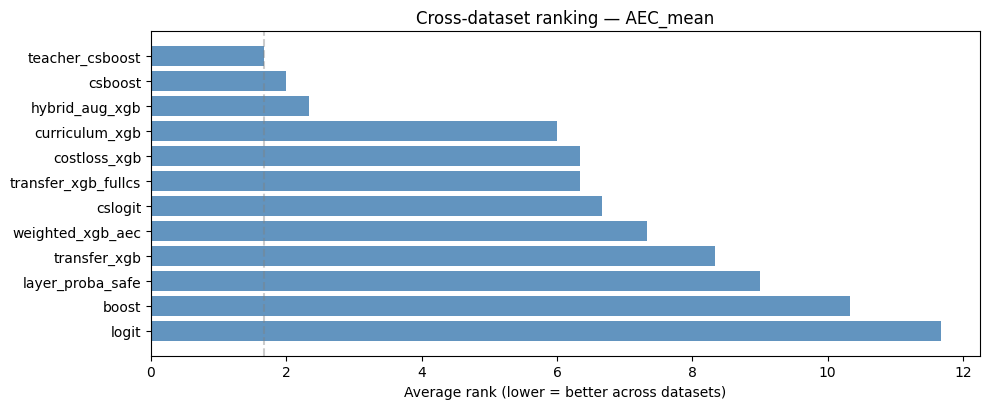

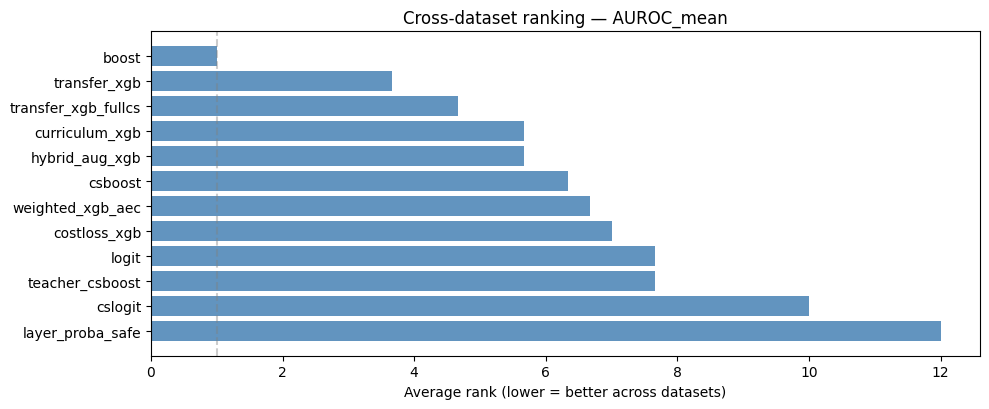

In [5]:
for col, _ in METRICS_CONFIG:
    avg_ranks = friedman_results[col]['avg_ranks']
    fig, ax = plt.subplots(figsize=(10, max(3.0, 0.35 * len(avg_ranks))))
    order = avg_ranks.sort_values().index.tolist()
    y = np.arange(len(order))
    ax.barh(y, avg_ranks.loc[order].values, color='steelblue', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(order)
    ax.invert_yaxis()
    ax.set_xlabel('Average rank (lower = better across datasets)')
    ax.set_title(f'Cross-dataset ranking — {col}')
    ax.axvline(avg_ranks.min(), color='gray', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Optional: load from CSV instead of notebooks

If you prefer to load from CSV instead of parsing notebooks, use **datasets as rows** and **models as columns** (same layout as `results/cross_dataset_aec.csv` / `cross_dataset_auroc.csv`). Set `USE_CSV = True` and `CSV_PATH` / `CSV_PATH_AUROC` in the next cell.

In [6]:
USE_CSV = False
CSV_PATH = REPO_ROOT / 'results' / 'cross_dataset_aec.csv'
CSV_PATH_AUROC = REPO_ROOT / 'results' / 'cross_dataset_auroc.csv'

if USE_CSV and CSV_PATH.is_file() and CSV_PATH_AUROC.is_file():
    M_aec = pd.read_csv(CSV_PATH, index_col=0)
    M_auroc = pd.read_csv(CSV_PATH_AUROC, index_col=0)
    M_BY_METRIC = {'AEC_mean': M_aec, 'AUROC_mean': M_auroc}
    friedman_results = {}
    for col, rank_asc in METRICS_CONFIG:
        M = M_BY_METRIC[col]
        _, _, avg_ranks, friedman_stat, friedman_p = friedman_rank_across_datasets(
            M, rank_ascending=rank_asc
        )
        n_ds = len(M)
        n_m = len(M.columns)
        cd = nemenyi_cd(n_models=n_m, n_blocks=n_ds, alpha=ALPHA)
        pairwise_diff = nemenyi_pairwise_abs_rank_diff(avg_ranks)
        pairwise_sig = nemenyi_pairwise_significant(avg_ranks, cd)
        pairwise_long = nemenyi_pairwise_long_table(avg_ranks, cd)
        friedman_results[col] = {
            'avg_ranks': avg_ranks,
            'friedman_stat': friedman_stat,
            'friedman_p': friedman_p,
            'cd': cd,
            'pairwise_abs_rank_diff': pairwise_diff,
            'pairwise_nemenyi_sig': pairwise_sig,
            'pairwise_long': pairwise_long,
        }
        print(col, 'chi2=', friedman_stat, 'p=', friedman_p, 'CD=', cd)
        display(avg_ranks.rename('average_rank').to_frame())
        display(pairwise_diff.round(4))
        display(pairwise_sig)
        sig_only = pairwise_long.loc[pairwise_long['nemenyi_significant']].sort_values(
            '|rank_diff|', ascending=False
        )
        display(sig_only.reset_index(drop=True))
        out_dir = REPO_ROOT / 'results'
        out_dir.mkdir(parents=True, exist_ok=True)
        slug = col.lower().replace('_', '')
        pairwise_diff.round(6).to_csv(out_dir / f'nemenyi_pairwise_absdiff_{slug}.csv')
        pairwise_sig.to_csv(out_dir / f'nemenyi_pairwise_sig_{slug}.csv')
        pairwise_long.to_csv(out_dir / f'nemenyi_pairwise_long_{slug}.csv', index=False)
else:
    print('Set USE_CSV = True after exporting both CSVs, or rely on notebook parsing above.')

Set USE_CSV = True after exporting both CSVs, or rely on notebook parsing above.
